In [1]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from faraway.datasets import galapagos


# Load the galapagos dataset
data = galapagos.load()


# Display the first few rows
print(data.head())


# Display the column names and data types
print(data.info())

           Species   Area  Elevation  Nearest  Scruz  Adjacent
Baltra          58  25.09        346      0.6    0.6      1.84
Bartolome       31   1.24        109      0.6   26.3    572.33
Caldwell         3   0.21        114      2.8   58.7      0.78
Champion        25   0.10         46      1.9   47.4      0.18
Coamano          2   0.05         77      1.9    1.9    903.82
<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, Baltra to Wolf
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Species    30 non-null     int64  
 1   Area       30 non-null     float64
 2   Elevation  30 non-null     int64  
 3   Nearest    30 non-null     float64
 4   Scruz      30 non-null     float64
 5   Adjacent   30 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 1.6+ KB
None


In [2]:
X = data[['Area', 'Elevation', 'Nearest']]
y = data['Species']

# Add a constant to the independent variables
X = sm.add_constant(X)

print(X.shape, y.shape)

(30, 4) (30,)


In [3]:
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Species   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     10.77
Date:                Sun, 31 May 2026   Prob (F-statistic):           8.82e-05
Time:                        08:53:01   Log-Likelihood:                -172.20
No. Observations:                  30   AIC:                             352.4
Df Residuals:                      26   BIC:                             358.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         16.4647     23.389      0.704      0.4

               Area  Elevation   Nearest
Area       1.000000   0.753735 -0.111103
Elevation  0.753735   1.000000 -0.011077
Nearest   -0.111103  -0.011077  1.000000


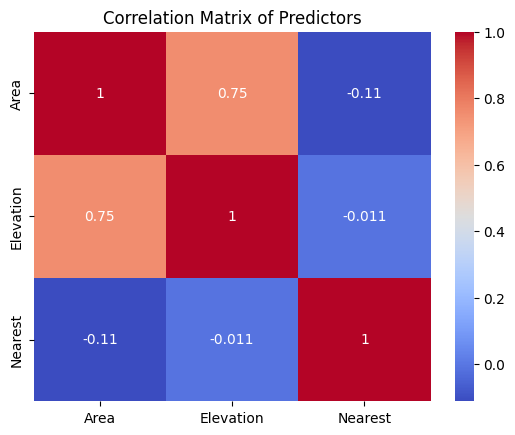

In [4]:
correlation_matrix = data[['Area', 'Elevation', 'Nearest']].corr()
print(correlation_matrix)

# Visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Predictors')
plt.show()

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define predictors (excluding the dependent variable 'Species')
X = data[['Area', 'Elevation', 'Nearest']]
# Add a constant to the predictors
X = sm.add_constant(X)

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data['Variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

    Variable       VIF
0      const  2.511156
1       Area  2.373470
2  Elevation  2.344460
3    Nearest  1.025189


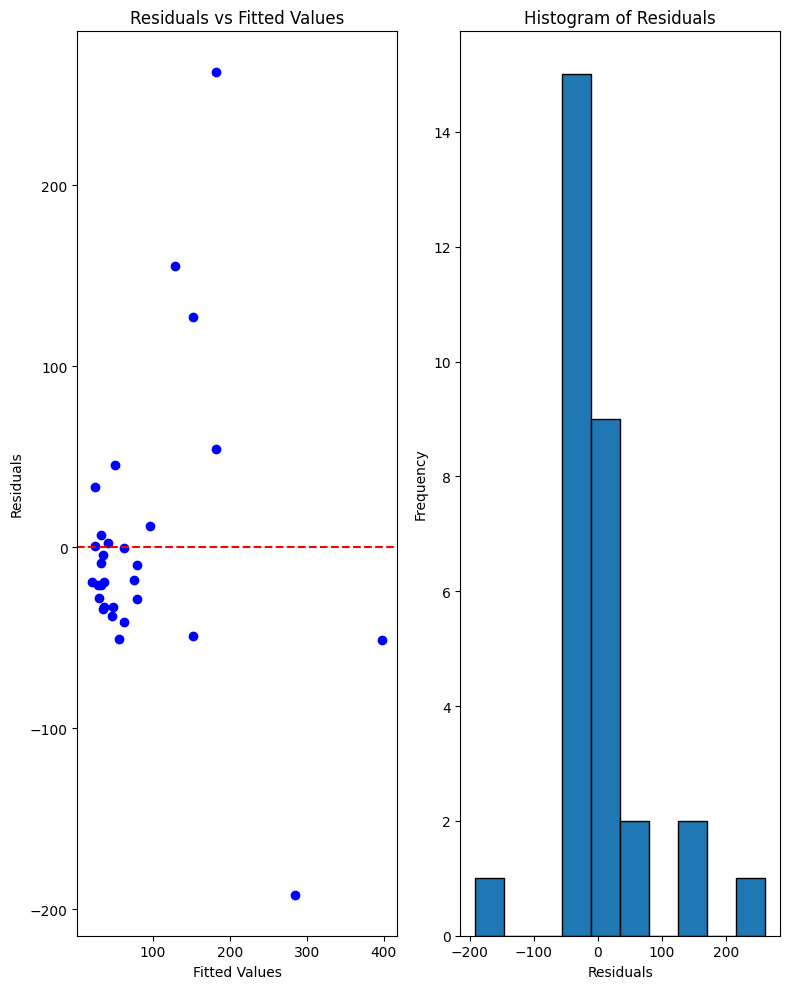

In [6]:
residuals = model.resid

# Create a 2x1 grid for the plots
fig, axes = plt.subplots(1, 2, figsize=(8, 10))  # 2 rows, 1 column


# Plot 1: Residuals vs Fitted Values
axes[0].scatter(model.fittedvalues, residuals, color='blue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')


# Plot 2: Histogram of Residuals
axes[1].hist(residuals, bins=10, edgecolor='black')
axes[1].set_title('Histogram of Residuals')
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Frequency')


# Adjust layout
plt.tight_layout()


# Show the plots
plt.show()

In [7]:
# Define new data for prediction
new_data = pd.DataFrame({'const': [1], 'Area': [10], 'Elevation': [100], 'Nearest': [1.5]})

# Predict the number of species
prediction = model.predict(new_data)
print(f"Predicted number of species: {prediction[0]:.2f}")

Predicted number of species: 33.90
